In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

PyTorch: 2.11.0+cu128
CUDA: True


In [3]:
DATA_FILE = "../data/processed/speech_features_adapted.csv"

LAMBDA = 0.5
RANDOM_STATE = 42
BATCH_SIZE = 64
EPOCHS = 30
LEARNING_RATE = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("Lambda:", LAMBDA)

Device: cuda
Lambda: 0.5


In [4]:
df = pd.read_csv(DATA_FILE)

print("Shape:", df.shape)
print(df["dataset"].value_counts())
print(df["emotion"].value_counts())

Shape: (10322, 51)
dataset
CREMA-D    7442
RAVDESS    2880
Name: count, dtype: int64
emotion
angry        1655
disgust      1655
fearful      1655
happy        1655
sad          1655
neutral      1279
calm          384
surprised     384
Name: count, dtype: int64


In [5]:
exclude_cols = [
    "file_id",
    "dataset",
    "file",
    "speaker",
    "emotion",
    "emotion_id"
]

feature_cols = [
    col for col in df.columns
    if col not in exclude_cols
]

X = df[feature_cols].apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.median())

y_emotion = df["emotion"].values
y_domain = df["dataset"].map({
    "CREMA-D": 0,
    "RAVDESS": 1
}).values

print("Features:", len(feature_cols))
print("X shape:", X.shape)

Features: 45
X shape: (10322, 45)


In [6]:
label_encoder = LabelEncoder()

y_emotion_encoded = label_encoder.fit_transform(y_emotion)

print("Emotion classes:")
print(label_encoder.classes_)

Emotion classes:
['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [7]:
stratify_labels = np.array([
    f"{e}_{d}"
    for e, d in zip(y_emotion_encoded, y_domain)
])

X_train, X_test, y_em_train, y_em_test, y_dom_train, y_dom_test = train_test_split(
    X,
    y_emotion_encoded,
    y_domain,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=stratify_labels
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (8257, 45)
Testing : (2065, 45)


In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train mean:", X_train.mean())
print("Train std :", X_train.std())

Train mean: 4.754927166088004e-17
Train std : 0.9888264649460884


In [9]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_em_train_tensor = torch.tensor(y_em_train, dtype=torch.long)
y_em_test_tensor = torch.tensor(y_em_test, dtype=torch.long)

y_dom_train_tensor = torch.tensor(y_dom_train, dtype=torch.long)
y_dom_test_tensor = torch.tensor(y_dom_test, dtype=torch.long)

train_dataset = TensorDataset(
    X_train_tensor,
    y_em_train_tensor,
    y_dom_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("Training batches:", len(train_loader))

Training batches: 130


In [10]:
class GradientReversal(torch.autograd.Function):

    @staticmethod
    def forward(ctx, x, lambda_value):
        ctx.lambda_value = lambda_value
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambda_value * grad_output, None


def gradient_reverse(x, lambda_value):
    return GradientReversal.apply(x, lambda_value)

In [11]:
class DANN(nn.Module):

    def __init__(self, input_dim, num_emotions, num_domains=2):
        super().__init__()

        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        self.emotion_classifier = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_emotions)
        )

        self.domain_classifier = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_domains)
        )

    def forward(self, x, lambda_value=0.5):

        features = self.feature_extractor(x)

        emotion_output = self.emotion_classifier(features)

        reversed_features = gradient_reverse(
            features,
            lambda_value
        )

        domain_output = self.domain_classifier(
            reversed_features
        )

        return emotion_output, domain_output

In [12]:
input_dim = X_train.shape[1]
num_emotions = len(label_encoder.classes_)

model = DANN(
    input_dim=input_dim,
    num_emotions=num_emotions
).to(device)

criterion_emotion = nn.CrossEntropyLoss()
criterion_domain = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print(model)

DANN(
  (feature_extractor): Sequential(
    (0): Linear(in_features=45, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
  )
  (emotion_classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=8, bias=True)
  )
  (domain_classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [13]:
history = {
    "emotion_loss": [],
    "domain_loss": [],
    "total_loss": []
}

for epoch in range(EPOCHS):

    model.train()

    total_emotion_loss = 0
    total_domain_loss = 0
    total_loss_value = 0

    for X_batch, y_em_batch, y_dom_batch in train_loader:

        X_batch = X_batch.to(device)
        y_em_batch = y_em_batch.to(device)
        y_dom_batch = y_dom_batch.to(device)

        optimizer.zero_grad()

        emotion_output, domain_output = model(
            X_batch,
            lambda_value=LAMBDA
        )

        emotion_loss = criterion_emotion(
            emotion_output,
            y_em_batch
        )

        domain_loss = criterion_domain(
            domain_output,
            y_dom_batch
        )

        total_loss = emotion_loss + LAMBDA * domain_loss

        total_loss.backward()
        optimizer.step()

        total_emotion_loss += emotion_loss.item()
        total_domain_loss += domain_loss.item()
        total_loss_value += total_loss.item()

    avg_emotion = total_emotion_loss / len(train_loader)
    avg_domain = total_domain_loss / len(train_loader)
    avg_total = total_loss_value / len(train_loader)

    history["emotion_loss"].append(avg_emotion)
    history["domain_loss"].append(avg_domain)
    history["total_loss"].append(avg_total)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Emotion Loss: {avg_emotion:.4f} | "
        f"Domain Loss: {avg_domain:.4f} | "
        f"Total Loss: {avg_total:.4f}"
    )

Epoch 01/30 | Emotion Loss: 1.8184 | Domain Loss: 0.6280 | Total Loss: 2.1324
Epoch 02/30 | Emotion Loss: 1.5481 | Domain Loss: 0.5982 | Total Loss: 1.8472
Epoch 03/30 | Emotion Loss: 1.4686 | Domain Loss: 0.5929 | Total Loss: 1.7651
Epoch 04/30 | Emotion Loss: 1.4179 | Domain Loss: 0.5957 | Total Loss: 1.7158
Epoch 05/30 | Emotion Loss: 1.3779 | Domain Loss: 0.5857 | Total Loss: 1.6708
Epoch 06/30 | Emotion Loss: 1.3558 | Domain Loss: 0.5885 | Total Loss: 1.6501
Epoch 07/30 | Emotion Loss: 1.3555 | Domain Loss: 0.5755 | Total Loss: 1.6432
Epoch 08/30 | Emotion Loss: 1.3265 | Domain Loss: 0.5761 | Total Loss: 1.6146
Epoch 09/30 | Emotion Loss: 1.3148 | Domain Loss: 0.5750 | Total Loss: 1.6023
Epoch 10/30 | Emotion Loss: 1.2872 | Domain Loss: 0.5687 | Total Loss: 1.5716
Epoch 11/30 | Emotion Loss: 1.2776 | Domain Loss: 0.5604 | Total Loss: 1.5578
Epoch 12/30 | Emotion Loss: 1.2546 | Domain Loss: 0.5569 | Total Loss: 1.5330
Epoch 13/30 | Emotion Loss: 1.2424 | Domain Loss: 0.5518 | Total

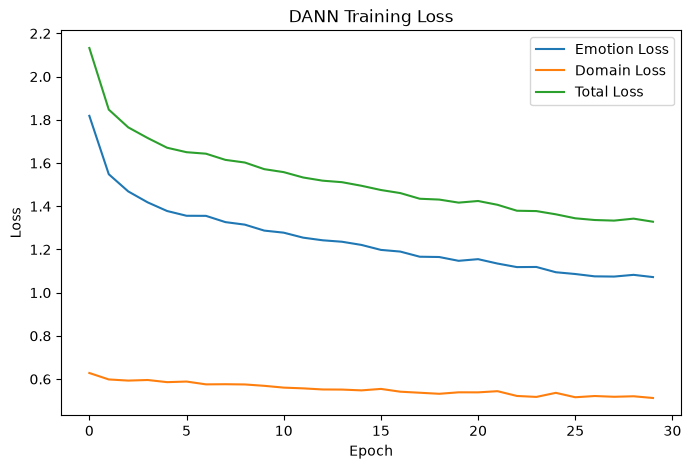

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(history["emotion_loss"], label="Emotion Loss")
plt.plot(history["domain_loss"], label="Domain Loss")
plt.plot(history["total_loss"], label="Total Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DANN Training Loss")
plt.legend()
plt.show()

In [16]:
model.eval()

with torch.no_grad():

    X_test_device = X_test_tensor.to(device)

    emotion_output, domain_output = model(
        X_test_device,
        lambda_value=0.0
    )

    emotion_predictions = torch.argmax(
        emotion_output,
        dim=1
    ).cpu().numpy()

    domain_predictions = torch.argmax(
        domain_output,
        dim=1
    ).cpu().numpy()

In [17]:
emotion_accuracy = accuracy_score(
    y_em_test,
    emotion_predictions
)

print("=" * 60)
print("EMOTION CLASSIFICATION")
print("=" * 60)

print("Accuracy:", emotion_accuracy)

print(
    classification_report(
        y_em_test,
        emotion_predictions,
        target_names=label_encoder.classes_
    )
)

EMOTION CLASSIFICATION
Accuracy: 0.553995157384988
              precision    recall  f1-score   support

       angry       0.70      0.71      0.70       331
        calm       0.81      0.73      0.77        77
     disgust       0.58      0.56      0.57       331
     fearful       0.46      0.53      0.49       331
       happy       0.56      0.42      0.48       331
     neutral       0.41      0.45      0.43       256
         sad       0.51      0.55      0.53       331
   surprised       0.74      0.75      0.75        77

    accuracy                           0.55      2065
   macro avg       0.60      0.59      0.59      2065
weighted avg       0.56      0.55      0.55      2065



In [18]:
domain_accuracy = accuracy_score(
    y_dom_test,
    domain_predictions
)

print("=" * 60)
print("DOMAIN CLASSIFICATION")
print("=" * 60)

print("Domain accuracy:", domain_accuracy)

print(
    classification_report(
        y_dom_test,
        domain_predictions,
        target_names=["CREMA-D", "RAVDESS"]
    )
)

DOMAIN CLASSIFICATION
Domain accuracy: 0.7656174334140435
              precision    recall  f1-score   support

     CREMA-D       0.77      0.97      0.86      1488
     RAVDESS       0.76      0.23      0.36       577

    accuracy                           0.77      2065
   macro avg       0.76      0.60      0.61      2065
weighted avg       0.77      0.77      0.72      2065



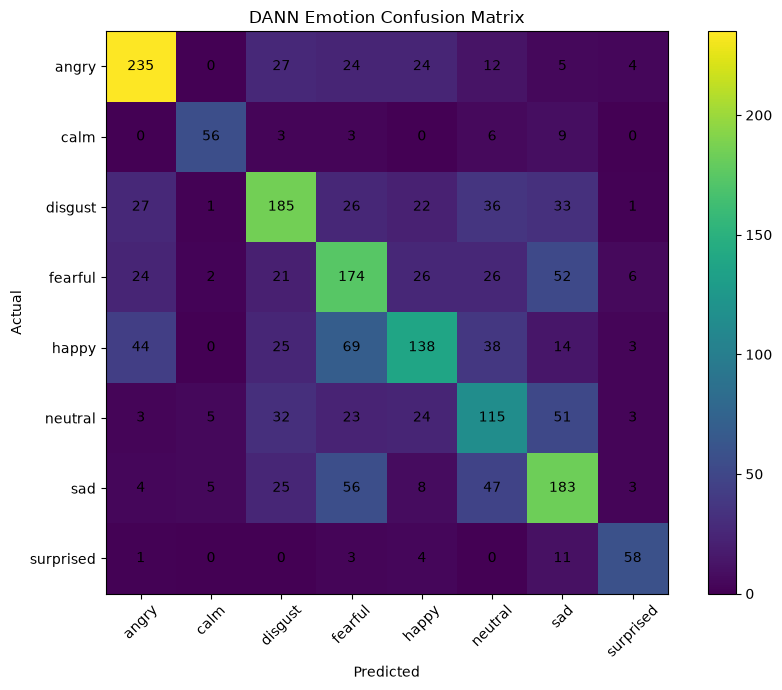

In [19]:
cm_emotion = confusion_matrix(
    y_em_test,
    emotion_predictions
)

plt.figure(figsize=(9, 7))

plt.imshow(cm_emotion)

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=45
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DANN Emotion Confusion Matrix")

plt.colorbar()

for i in range(cm_emotion.shape[0]):
    for j in range(cm_emotion.shape[1]):
        plt.text(
            j,
            i,
            cm_emotion[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

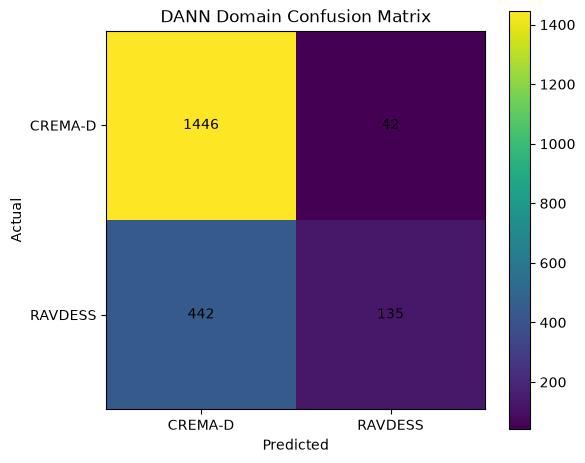

In [20]:
cm_domain = confusion_matrix(
    y_dom_test,
    domain_predictions
)

plt.figure(figsize=(6, 5))

plt.imshow(cm_domain)

plt.xticks(
    [0, 1],
    ["CREMA-D", "RAVDESS"]
)

plt.yticks(
    [0, 1],
    ["CREMA-D", "RAVDESS"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DANN Domain Confusion Matrix")

plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_domain[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [21]:
MODEL_PATH = "../data/processed/dann_final.pt"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "feature_columns": feature_cols,
        "emotion_classes": label_encoder.classes_.tolist(),
        "lambda": LAMBDA
    },
    MODEL_PATH
)

print("Model saved to:", MODEL_PATH)

Model saved to: ../data/processed/dann_final.pt


In [22]:
print("=" * 60)
print("FINAL DANN RESULTS")
print("=" * 60)

print(f"Lambda              : {LAMBDA}")
print(f"Emotion Accuracy    : {emotion_accuracy:.4f}")
print(f"Domain Accuracy     : {domain_accuracy:.4f}")

FINAL DANN RESULTS
Lambda              : 0.5
Emotion Accuracy    : 0.5540
Domain Accuracy     : 0.7656


In [23]:
SEEDS = [42, 52, 62, 72, 82]

results = []

for seed in SEEDS:

    torch.manual_seed(seed)
    np.random.seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = DANN(
        input_dim=input_dim,
        num_emotions=num_emotions
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    for epoch in range(EPOCHS):

        model.train()

        for X_batch, y_em_batch, y_dom_batch in train_loader:

            X_batch = X_batch.to(device)
            y_em_batch = y_em_batch.to(device)
            y_dom_batch = y_dom_batch.to(device)

            optimizer.zero_grad()

            emotion_output, domain_output = model(
                X_batch,
                lambda_value=LAMBDA
            )

            emotion_loss = criterion_emotion(
                emotion_output,
                y_em_batch
            )

            domain_loss = criterion_domain(
                domain_output,
                y_dom_batch
            )

            loss = emotion_loss + LAMBDA * domain_loss

            loss.backward()
            optimizer.step()

    model.eval()

    with torch.no_grad():

        emotion_output, domain_output = model(
            X_test_tensor.to(device),
            lambda_value=0.0
        )

        emotion_pred = torch.argmax(
            emotion_output,
            dim=1
        ).cpu().numpy()

        domain_pred = torch.argmax(
            domain_output,
            dim=1
        ).cpu().numpy()

    emotion_acc = accuracy_score(
        y_em_test,
        emotion_pred
    )

    domain_acc = accuracy_score(
        y_dom_test,
        domain_pred
    )

    report = classification_report(
        y_em_test,
        emotion_pred,
        output_dict=True
    )

    macro_f1 = report["macro avg"]["f1-score"]

    results.append({
        "seed": seed,
        "emotion_accuracy": emotion_acc,
        "emotion_macro_f1": macro_f1,
        "domain_accuracy": domain_acc
    })

results_df = pd.DataFrame(results)

print(results_df)

print("\nMean:")
print(results_df.mean(numeric_only=True))

print("\nStd:")
print(results_df.std(numeric_only=True))

   seed  emotion_accuracy  emotion_macro_f1  domain_accuracy
0    42          0.566102          0.612588         0.775787
1    52          0.551574          0.583612         0.769492
2    62          0.562712          0.597006         0.776271
3    72          0.561743          0.592457         0.767554
4    82          0.564649          0.599950         0.767070

Mean:
seed                62.000000
emotion_accuracy     0.561356
emotion_macro_f1     0.597123
domain_accuracy      0.771235
dtype: float64

Std:
seed                15.811388
emotion_accuracy     0.005724
emotion_macro_f1     0.010624
domain_accuracy      0.004473
dtype: float64


In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

baseline = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

baseline.fit(X_train, y_em_train)

baseline_pred = baseline.predict(X_test)

baseline_accuracy = accuracy_score(
    y_em_test,
    baseline_pred
)

print("=" * 60)
print("SUPERVISED BASELINE")
print("=" * 60)

print("Accuracy:", baseline_accuracy)

print(
    classification_report(
        y_em_test,
        baseline_pred,
        target_names=label_encoder.classes_
    )
)

SUPERVISED BASELINE
Accuracy: 0.6077481840193705
              precision    recall  f1-score   support

       angry       0.71      0.71      0.71       331
        calm       0.97      1.00      0.99        77
     disgust       0.58      0.56      0.57       331
     fearful       0.59      0.45      0.51       331
       happy       0.57      0.53      0.55       331
     neutral       0.43      0.55      0.48       256
         sad       0.59      0.65      0.62       331
   surprised       0.91      1.00      0.95        77

    accuracy                           0.61      2065
   macro avg       0.67      0.68      0.67      2065
weighted avg       0.61      0.61      0.61      2065



In [25]:
from sklearn.metrics import f1_score

baseline_f1 = f1_score(
    y_em_test,
    baseline_pred,
    average="macro"
)

print("Macro F1:", baseline_f1)

Macro F1: 0.6727003805208109
